# Week 1, Notebook 1: The Single Neuron
## Pure Python + NumPy — No Frameworks

**What you'll build:** A single neuron from scratch, trained with gradient descent.

**Curriculum points:** 
- ② ReLU changed everything (sigmoid vs ReLU comparison)
- ④ Neural networks don't "understand" — they minimize loss
- ⑤ Backpropagation is just the chain rule

**Time estimate:** 30–45 minutes

---
### Key Insight
A neuron is just: `output = activation(weights · inputs + bias)`  
That's it. Everything else is optimization.

## Part 1: Build a Single Neuron

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# ============================================================
# A single neuron: the atom of deep learning
# ============================================================
# A neuron computes: z = w·x + b, then a = activation(z)
# Let's build one from absolute zero.

class Neuron:
    """A single artificial neuron."""
    
    def __init__(self, n_inputs, activation='sigmoid'):
        # Initialize weights randomly (small values)
        self.w = np.random.randn(n_inputs) * 0.1
        self.b = 0.0
        self.activation = activation
        
        # Storage for backprop
        self.z = None    # pre-activation
        self.a = None    # post-activation  
        self.x = None    # input (cached)
    
    def _activate(self, z):
        """Apply activation function."""
        if self.activation == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        elif self.activation == 'relu':
            return np.maximum(0, z)
        elif self.activation == 'linear':
            return z
    
    def _activate_derivative(self, z):
        """Derivative of activation — needed for backprop."""
        if self.activation == 'sigmoid':
            s = self._activate(z)
            return s * (1 - s)
        elif self.activation == 'relu':
            return (z > 0).astype(float)
        elif self.activation == 'linear':
            return np.ones_like(z)
    
    def forward(self, x):
        """Forward pass: compute output."""
        self.x = x
        self.z = np.dot(x, self.w) + self.b   # linear combination
        self.a = self._activate(self.z)         # apply activation
        return self.a
    
    def __repr__(self):
        return f"Neuron(w={self.w}, b={self.b:.4f}, act={self.activation})"

# Create a neuron with 2 inputs
neuron = Neuron(n_inputs=2, activation='sigmoid')
print("Our neuron:", neuron)

# Pass some data through it
x_sample = np.array([1.0, 0.5])
output = neuron.forward(x_sample)
print(f"Input: {x_sample} → Output: {output:.4f}")

Our neuron: Neuron(w=[ 0.04967142 -0.01382643], b=0.0000, act=sigmoid)
Input: [1.  0.5] → Output: 0.5107


### 🧠 What just happened?
The neuron:
1. Multiplied each input by its weight
2. Added the bias
3. Squeezed the result through sigmoid (maps everything to 0–1)

**Key question:** *Can this single neuron learn anything useful?*

Let's find out by training it on logic gates.

## Part 2: Train the Neuron — AND Gate

This function `train_neuron(neuron, X, y, learning_rate=0.5, epochs=1000, verbose=True)` trains a single neuron using batch gradient descent. It takes a `neuron` object, a matrix of inputs `X`, the target outputs `y`, and a few training settings such as `learning_rate`, `epochs`, and `verbose`. Its job is to repeatedly run the neuron on the training data, measure how wrong the predictions are, compute gradients with backpropagation, and then update the neuron's weights and bias to reduce the error over time.

The `losses = []` list stores the loss value from every epoch so the training process can be visualized later. The outer loop, `for epoch in range(epochs):`, represents repeated training passes over the whole dataset. Each full pass is one epoch. Inside that loop, the line `predictions = np.array([neuron.forward(x) for x in X])` computes the neuron's output for every sample in `X`. Those outputs are collected into a NumPy array, and `mse_loss(predictions, y)` computes the mean squared error between predictions and true labels. That loss is appended to `losses`, which allows plotting how learning progresses.

After the forward pass, the function prepares to compute gradients. `dw = np.zeros_like(neuron.w)` creates a zero vector with the same shape as the weight vector, so each weight can accumulate its gradient contribution. `db = 0.0` does the same for the bias. These variables are accumulators because the code sums the gradient from every training sample before applying the update. That makes this batch gradient descent rather than updating after each individual sample.

The inner loop iterates through each example in the dataset. For each sample, `neuron.forward(X[i])` is called again so the neuron's cached values such as `x`, `z`, and `a` are refreshed for that specific input. This is important because the backpropagation step depends on those stored intermediate values. It is slightly inefficient because the predictions were already computed once earlier, but it keeps the code easy to follow for learning purposes.

The next three lines implement the chain rule directly. `dL_da` is the derivative of the mean squared error with respect to the neuron's output $a$, written as $2(a - y)/N$, where $N$ is the number of samples. `da_dz` is the derivative of the activation function with respect to the pre-activation value $z`. This depends on whether the neuron is using sigmoid, ReLU, or linear activation. `dz_dw` is simply the input `x`, because for $z = w \cdot x + b$, the derivative of $z$ with respect to each weight is the corresponding input value.

Those partial derivatives are multiplied together to form the gradient with respect to the weights: $dL/dw = dL/da \cdot da/dz \cdot dz/dw$. The line `dw += dL_da * da_dz * dz_dw` adds that sample’s contribution to the total weight gradient. The bias gradient is similar, except $dz/db = 1$, so `db += dL_da * da_dz * 1.0`. By the end of the inner loop, `dw` and `db` contain the full gradient of the loss across the dataset.

Once the gradients are ready, the parameters are updated with gradient descent. The lines `neuron.w -= learning_rate * dw` and `neuron.b -= learning_rate * db` move the weights and bias in the direction that reduces the loss. The learning rate controls the step size. If it is too small, learning will be slow; if it is too large, training may overshoot or become unstable.

The optional print block shows progress every 200 epochs. It reports the epoch number, the current loss, the weight vector, and the bias. This is useful for checking whether training is improving or getting stuck. Finally, the function returns the `losses` list so the caller can inspect or plot the training curve.

A small gotcha is that this implementation is intentionally educational, not optimized. It recomputes each forward pass during backpropagation and uses explicit Python loops, which are slower than vectorized NumPy code. Even so, it clearly shows the core idea: backpropagation is just repeated application of the chain rule to compute how each parameter affects the final loss.

In [ ]:
# ============================================================
# Training data: AND gate
# ============================================================
# AND: output is 1 only when BOTH inputs are 1
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# Loss function: Mean Squared Error
def mse_loss(predicted, actual):
    return np.mean((predicted - actual) ** 2)

# ============================================================
# Training loop — gradient descent by hand
# this is the essence of backpropagation for a single neuron
# that's what we need to understand before we can build a full network
# ============================================================
def train_neuron(neuron, X, y, learning_rate=0.5, epochs=1000, verbose=True):
    """Train a single neuron using gradient descent.
    A neuron has parameters (weights and bias) that we want to adjust to minimize the loss on our training data.
    A neuron computes: z = w·x + b, then a = activation(z)
    a is the output of the neuron, which we want to match the target y.
    x is the input, w are the weights, and b is the bias.
    
    This is backprop for ONE neuron:    # compute gradients of loss w.r.t. weights and bias, then update.
    - Loss = (1/N) Σ (a - y)²           # mean squared error
    - dL/da = 2(a - y) / N              # gradient of loss w.r.t. activation output
    - da/dz = activation'(z)       ← chain rule!        # gradient of activation w.r.t. pre-activation
    - dz/dw = x                    ← chain rule again!  # gradient of pre-activation w.r.t. weights
    - dz/db = 1                    ← chain rule again!  # gradient of pre-activation w.r.t. bias
    
    So: dL/dw = dL/da · da/dz · dz/dw = dL/da · activation'(z) · x # gradient for weights
    So: dL/db = dL/da · da/dz · dz/db = dL/da · activation'(z) · 1 # gradient for bias
        - Update: w -= learning_rate * dL/dw
                    b -= learning_rate * dL/db
                    
    """
    losses = []
    
    for epoch in range(epochs):
        # Forward pass (all samples at once)
        predictions = np.array([neuron.forward(x) for x in X]) # shape (N,) 
        loss = mse_loss(predictions, y) # compute loss
        losses.append(loss) # store loss for plotting
        
        # Backward pass — compute gradients
        dw = np.zeros_like(neuron.w) # gradient for weights
        db = 0.0 # gradient for bias
        
        for i in range(len(X)):
            neuron.forward(X[i])  # recompute (sets cached values)
            
            # Chain rule in action:
            dL_da = 2 * (neuron.a - y[i]) / len(X)          # loss gradient
            da_dz = neuron._activate_derivative(neuron.z)     # activation gradient
            dz_dw = neuron.x                                  # input
            
            # Combine via chain rule: dL/dw = dL/da · da/dz · dz/dw
            dw += dL_da * da_dz * dz_dw # accumulate over samples
            db += dL_da * da_dz * 1.0 # bias gradient (dz/db = 1)
        
        # Update weights (gradient descent step)
        neuron.w -= learning_rate * dw # update weights
        neuron.b -= learning_rate * db # update bias
        
        if verbose and epoch % 200 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {neuron.w} | b: {neuron.b:.4f}")
    
    return losses

# Train!
neuron_and = Neuron(2, activation='sigmoid')
losses = train_neuron(neuron_and, X_and, y_and, learning_rate=2.0, epochs=2000)

# Test
print("\n--- AND Gate Results ---")
for x, y_true in zip(X_and, y_and):
    pred = neuron_and.forward(x)
    print(f"  {x} → {pred:.4f} (target: {y_true})")

Epoch    0 | Loss: 0.251190 | w: [0.04604043 0.12876235] | b: -0.2775
Epoch  200 | Loss: 0.015698 | w: [3.50515591 3.50516245] | b: -5.3665
Epoch  400 | Loss: 0.007303 | w: [4.37633356 4.37633373] | b: -6.6639
Epoch  600 | Loss: 0.004647 | w: [4.87292187 4.87292189] | b: -7.4053
Epoch  800 | Loss: 0.003377 | w: [5.21752489 5.2175249 ] | b: -7.9202
Epoch 1000 | Loss: 0.002641 | w: [5.48037157 5.48037157] | b: -8.3132
Epoch 1200 | Loss: 0.002163 | w: [5.69235576 5.69235576] | b: -8.6303
Epoch 1400 | Loss: 0.001828 | w: [5.86972852 5.86972852] | b: -8.8957
Epoch 1600 | Loss: 0.001581 | w: [6.02206594 6.02206594] | b: -9.1237
Epoch 1800 | Loss: 0.001392 | w: [6.1554743 6.1554743] | b: -9.3234

--- AND Gate Results ---
  [0 0] → 0.0001 (target: 0)
  [0 1] → 0.0382 (target: 0)
  [1 0] → 0.0382 (target: 0)
  [1 1] → 0.9547 (target: 1)


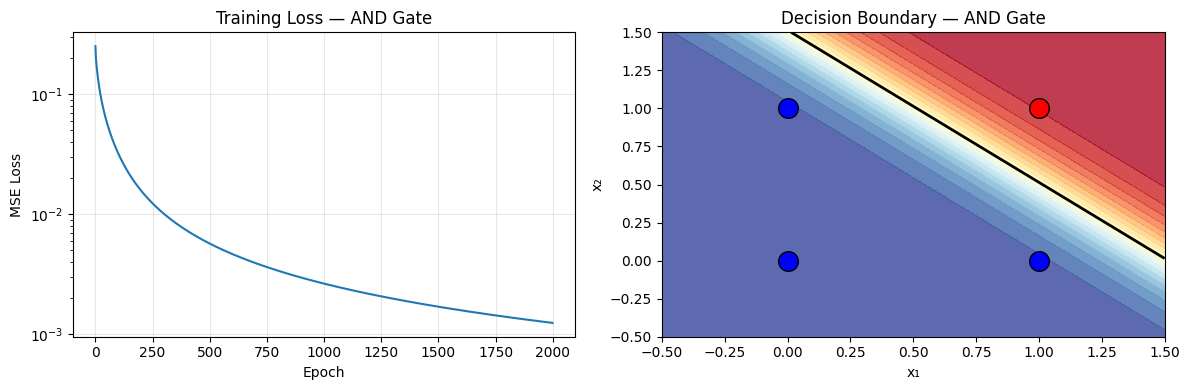

✓ Saved figure


In [3]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss — AND Gate')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.array([neuron_and.forward(p) for p in grid]).reshape(xx.shape)

axes[1].contourf(xx, yy, zz, levels=20, cmap='RdYlBu_r', alpha=0.8)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
for x, y_true in zip(X_and, y_and):
    color = 'red' if y_true == 1 else 'blue'
    axes[1].scatter(x[0], x[1], c=color, s=200, edgecolors='black', zorder=5)
axes[1].set_title('Decision Boundary — AND Gate')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')

plt.tight_layout()
plt.savefig('w1_01_and_gate.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved figure")

## Part 3: Sigmoid vs. ReLU — Why ReLU Changed Everything

**Curriculum Point ②:** Before ReLU, sigmoid and tanh dominated. The problem: *vanishing gradients*.

Let's SEE this problem.

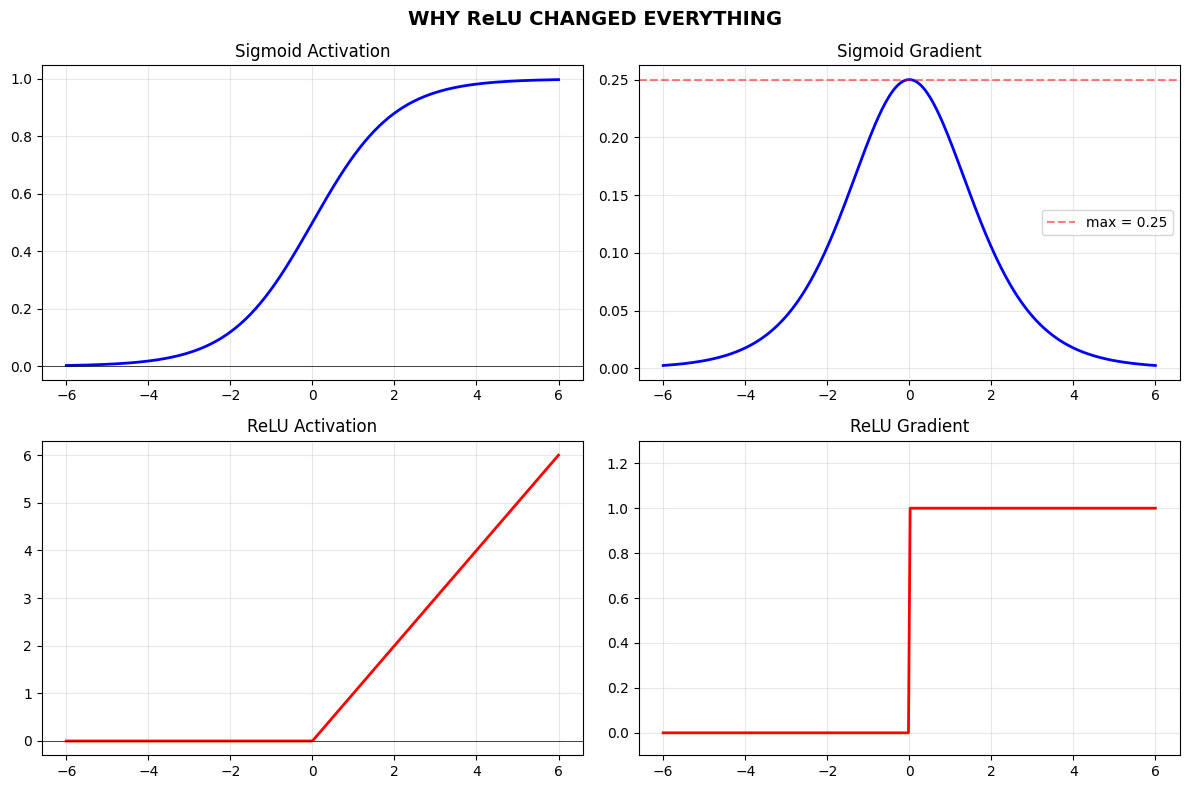

KEY INSIGHT:
  Sigmoid max gradient: 0.25 — multiplied across layers, this VANISHES
  ReLU gradient (when active): 1.00 — gradients flow unchanged!
  This is why deep networks couldn't train before ReLU.


In [4]:
# ============================================================
# SIGMOID vs RELU: visualize the gradient problem
# ============================================================
z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sigmoid and its derivative
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_grad = sigmoid * (1 - sigmoid)
axes[0, 0].plot(z, sigmoid, 'b-', linewidth=2)
axes[0, 0].set_title('Sigmoid Activation')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linewidth=0.5)

axes[0, 1].plot(z, sigmoid_grad, 'b-', linewidth=2)
axes[0, 1].set_title('Sigmoid Gradient')
axes[0, 1].axhline(y=0.25, color='r', linestyle='--', alpha=0.5, label='max = 0.25')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ReLU and its derivative
relu = np.maximum(0, z)
relu_grad = (z > 0).astype(float)
axes[1, 0].plot(z, relu, 'r-', linewidth=2)
axes[1, 0].set_title('ReLU Activation')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linewidth=0.5)

axes[1, 1].plot(z, relu_grad, 'r-', linewidth=2)
axes[1, 1].set_title('ReLU Gradient')
axes[1, 1].set_ylim(-0.1, 1.3)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('WHY ReLU CHANGED EVERYTHING', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('w1_01_relu_vs_sigmoid.png', dpi=100, bbox_inches='tight')
plt.show()

print("KEY INSIGHT:")
print(f"  Sigmoid max gradient: {sigmoid_grad.max():.2f} — multiplied across layers, this VANISHES")
print(f"  ReLU gradient (when active): 1.00 — gradients flow unchanged!")
print(f"  This is why deep networks couldn't train before ReLU.")

## Part 4: The XOR Challenge

**Can a single neuron learn XOR?** Try it and observe the failure.

XOR: output is 1 when inputs DIFFER.

--- XOR Gate Results (Single Neuron) ---
  [0 0] → 0.5000 (target: 0)
  [0 1] → 0.5000 (target: 1)
  [1 0] → 0.5000 (target: 1)
  [1 1] → 0.5000 (target: 0)

Final loss: 0.250000

⚠️  The neuron CANNOT learn XOR!
   A single neuron draws a LINEAR decision boundary.
   XOR is not linearly separable.
   → This is why we need MULTIPLE LAYERS (next notebook).


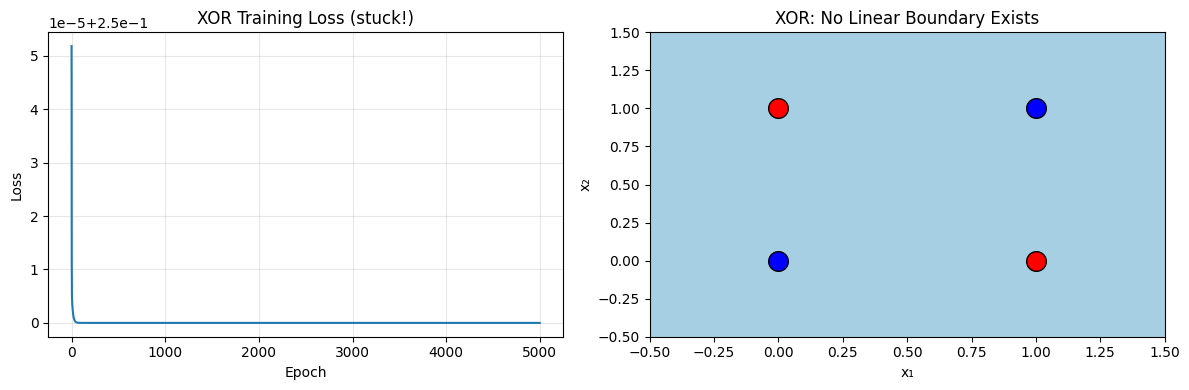

In [5]:
# ============================================================
# XOR gate — THE classic single-neuron failure case
# ============================================================
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

neuron_xor = Neuron(2, activation='sigmoid')
losses_xor = train_neuron(neuron_xor, X_xor, y_xor, learning_rate=2.0, epochs=5000, verbose=False)

print("--- XOR Gate Results (Single Neuron) ---")
for x, y_true in zip(X_xor, y_xor):
    pred = neuron_xor.forward(x)
    print(f"  {x} → {pred:.4f} (target: {y_true})")

print(f"\nFinal loss: {losses_xor[-1]:.6f}")
print("\n⚠️  The neuron CANNOT learn XOR!")
print("   A single neuron draws a LINEAR decision boundary.")
print("   XOR is not linearly separable.")
print("   → This is why we need MULTIPLE LAYERS (next notebook).")

# Visualize the failure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_xor)
axes[0].set_title('XOR Training Loss (stuck!)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = np.array([neuron_xor.forward(p) for p in grid]).reshape(xx.shape)
axes[1].contourf(xx, yy, zz, levels=20, cmap='RdYlBu_r', alpha=0.8)
for x, y_true in zip(X_xor, y_xor):
    color = 'red' if y_true == 1 else 'blue'
    axes[1].scatter(x[0], x[1], c=color, s=200, edgecolors='black', zorder=5)
axes[1].set_title('XOR: No Linear Boundary Exists')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')

plt.tight_layout()
plt.savefig('w1_01_xor_failure.png', dpi=100, bbox_inches='tight')
plt.show()

## ✅ Self-Check: "You know you've got it when..."

- [ ] You can explain what `z = w·x + b` computes geometrically (a hyperplane)
- [ ] You can explain in ONE sentence why ReLU fixes vanishing gradients
  - *Answer: ReLU's gradient is either 0 or 1 — it never shrinks, so gradients don't vanish when multiplied across layers.*
- [ ] You understand why XOR fails: a single neuron = a single linear boundary
- [ ] You wrote the gradient descent update rule without looking

## 🎯 Challenge (5 min)
Modify the code above to train an OR gate and a NAND gate. Compare the learned weights.

## ➡️ Next: `W1_02_Pure_Backprop_From_Scratch.ipynb` — Multi-neuron backpropagation

## Part 5: Drawing the Single Neuron Network

Let us visualize the neural network architecture of the single neuron we trained using `networkx`.

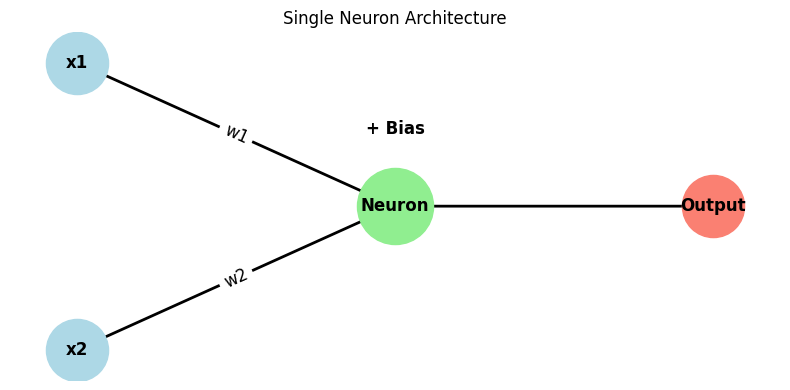

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_node("x1", pos=(0, 1))
G.add_node("x2", pos=(0, -1))
G.add_node("Neuron", pos=(2, 0))
G.add_node("Output", pos=(4, 0))

# Add edges
G.add_edge("x1", "Neuron", weight="w1")
G.add_edge("x2", "Neuron", weight="w2")
G.add_edge("Neuron", "Output", weight="")

# Get positions
pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(8, 4))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=["x1", "x2"], node_color="lightblue", node_size=2000)
nx.draw_networkx_nodes(G, pos, nodelist=["Neuron"], node_color="lightgreen", node_size=3000, node_shape="o")
nx.draw_networkx_nodes(G, pos, nodelist=["Output"], node_color="salmon", node_size=2000)

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, width=2)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

# Add bias text
plt.text(2, 0.5, "+ Bias", fontsize=12, fontweight="bold", ha="center")

plt.title("Single Neuron Architecture")
plt.axis("off")
plt.tight_layout()
plt.savefig("w1_01_neuron_arch.png", dpi=100, bbox_inches="tight")
plt.show()
